# Text Classification with OpenAI Embeddings + PCA

This notebook implements a minimal sklearn-style binary text classification pipeline:

1. Load text dataset (`text`, `label`)
2. Split data 75/25 (train/test)
3. Generate OpenAI embeddings
4. Reduce dimensions with PCA
5. Train Logistic Regression classifier
6. Evaluate with metrics and visualizations


## Setup

- Download UCI SMS Spam dataset file (`SMSSpamCollection`) and set `RAW_DATA_PATH` below.

In [46]:
from __future__ import annotations

import hashlib
import json
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
from openai import OpenAI
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt


In [47]:
RAW_DATA_PATH = Path("SMSSpamCollection")  # update if needed
CACHE_PATH = Path(".embedding_cache_sms.json")
EMBEDDING_MODEL = "text-embedding-3-small"
TEST_SIZE = 0.25
RANDOM_STATE = 42
PCA_COMPONENTS = 100
BATCH_SIZE = 64

if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset file not found: {RAW_DATA_PATH}")

# UCI format: label\ttext
df = pd.read_csv(RAW_DATA_PATH, sep="\t", header=None, names=["raw_label", "text"])
df["label"] = (df["raw_label"].str.lower() == "spam").astype(int)
df = df[["text", "label"]].dropna().copy()

print(df.head())
print("\nClass counts:\n", df["label"].value_counts())
print("Total samples:", len(df))


                                                text  label
0  Go until jurong point, crazy.. Available only ...      0
1                      Ok lar... Joking wif u oni...      0
2  Free entry in 2 a wkly comp to win FA Cup fina...      1
3  U dun say so early hor... U c already then say...      0
4  Nah I don't think he goes to usf, he lives aro...      0

Class counts:
 label
0    4825
1     747
Name: count, dtype: int64
Total samples: 5572


In [48]:
def text_key(text: str, model: str) -> str:
    return hashlib.sha256(f"{model}::{text}".encode("utf-8")).hexdigest()


def chunked(items: list[str], size: int) -> Iterable[list[str]]:
    for i in range(0, len(items), size):
        yield items[i : i + size]


def load_cache(path: Path) -> dict[str, list[float]]:
    if not path.exists():
        return {}
    return json.loads(path.read_text(encoding="utf-8"))


def save_cache(path: Path, cache: dict[str, list[float]]) -> None:
    path.write_text(json.dumps(cache), encoding="utf-8")


def embed_texts(client: OpenAI, texts: list[str], model: str, batch_size: int, cache_path: Path) -> np.ndarray:
    cache = load_cache(cache_path)
    missing = [t for t in texts if text_key(t, model) not in cache]

    for batch in chunked(missing, batch_size):
        response = client.embeddings.create(model=model, input=batch)
        for text, item in zip(batch, response.data):
            cache[text_key(text, model)] = item.embedding

    if missing:
        save_cache(cache_path, cache)

    vectors = [cache[text_key(t, model)] for t in texts]
    return np.array(vectors, dtype=np.float32)


In [49]:
x_train_text, x_test_text, y_train, y_test = train_test_split(
    df["text"].tolist(),
    df["label"].to_numpy(),
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df["label"].to_numpy(),
)

print("Train size:", len(x_train_text))
print("Test size:", len(x_test_text))


Train size: 4179
Test size: 1393


In [50]:
client = OpenAI()  # uses OPENAI_API_KEY from environment

x_train_embed = embed_texts(client, x_train_text, EMBEDDING_MODEL, BATCH_SIZE, CACHE_PATH)
x_test_embed = embed_texts(client, x_test_text, EMBEDDING_MODEL, BATCH_SIZE, CACHE_PATH)

max_components = min(x_train_embed.shape[1], x_train_embed.shape[0] - 1)
n_components = min(PCA_COMPONENTS, max_components)
pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
x_train_reduced = pca.fit_transform(x_train_embed)
x_test_reduced = pca.transform(x_test_embed)

clf = LogisticRegression(max_iter=1000)
clf.fit(x_train_reduced, y_train)
y_pred = clf.predict(x_test_reduced)
y_prob = clf.predict_proba(x_test_reduced)[:, 1]

print("Embedding shape (train):", x_train_embed.shape)
print("PCA components used:", n_components)
print("Explained variance ratio sum:", round(float(pca.explained_variance_ratio_.sum()), 4))


Embedding shape (train): (4179, 1536)
PCA components used: 100
Explained variance ratio sum: 0.5667


In [51]:
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1-score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy : 0.9907
Precision: 0.9943
Recall   : 0.9358
F1-score : 0.9642
ROC-AUC  : 0.9978

Classification report:

              precision    recall  f1-score   support

           0     0.9901    0.9992    0.9946      1206
           1     0.9943    0.9358    0.9642       187

    accuracy                         0.9907      1393
   macro avg     0.9922    0.9675    0.9794      1393
weighted avg     0.9907    0.9907    0.9905      1393

Confusion matrix:
 [[1205    1]
 [  12  175]]


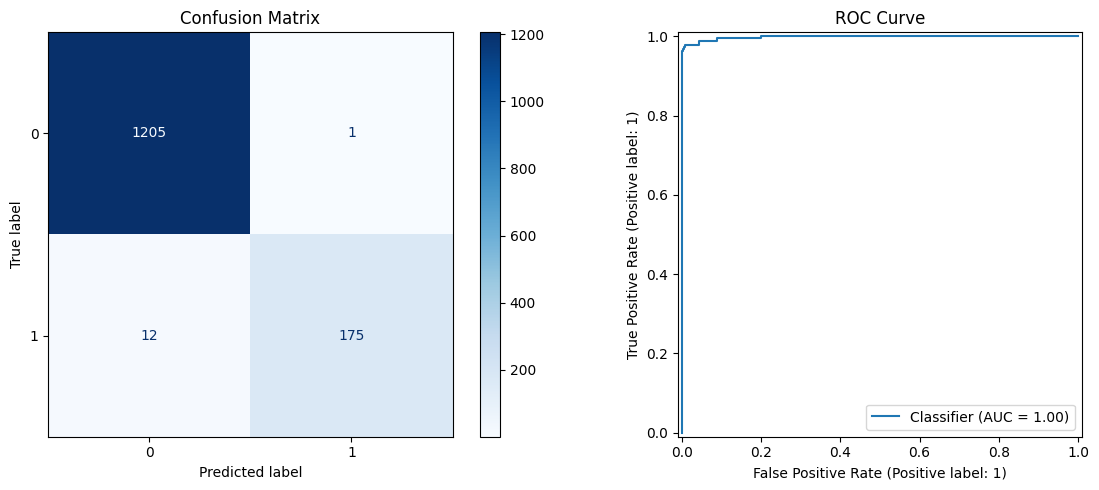

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
axes[1].set_title("ROC Curve")

plt.tight_layout()
plt.show()


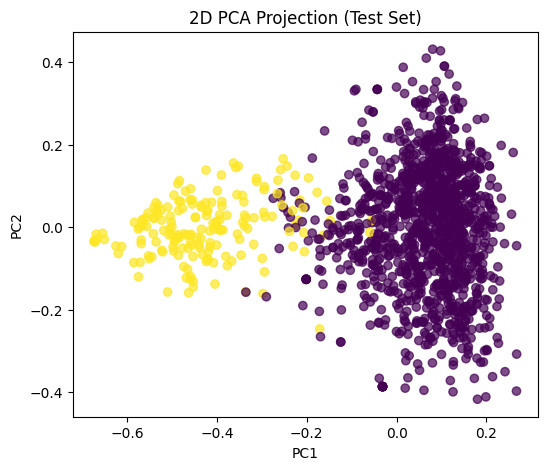

In [53]:
# Optional: 2D PCA visualization of test embeddings
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
x_test_2d = pca_2d.fit_transform(x_test_embed)

plt.figure(figsize=(6, 5))
plt.scatter(x_test_2d[:, 0], x_test_2d[:, 1], c=y_test, alpha=0.7)
plt.title("2D PCA Projection (Test Set)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()



- Model 1: TF-IDF + Naive Bayes (baseline)
- Model 2: TF-IDF -> TruncatedSVD -> Logistic Regression
- Model 3: TF-IDF -> PCA -> Logistic Regression



In [54]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)


### Step 1: Data loading and preprocessing

In [55]:
RAW_DATA_PATH = Path("SMSSpamCollection")
TEST_SIZE = 0.25
RANDOM_STATE = 42
MAX_FEATURES = 5000
N_COMPONENTS = 100

if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset file not found: {RAW_DATA_PATH}")

df = pd.read_csv(RAW_DATA_PATH, sep="\t", header=None, names=["raw_label", "text"])
df["label"] = (df["raw_label"].str.lower() == "spam").astype(int)
df = df[["text", "label"]].dropna().copy()

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["text"],
    df["label"],
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df["label"],
)

print(df.head())
print("\nClass distribution:\n", df["label"].value_counts())
print(f"\nTrain size: {len(X_train_text)}, Test size: {len(X_test_text)}")

                                                text  label
0  Go until jurong point, crazy.. Available only ...      0
1                      Ok lar... Joking wif u oni...      0
2  Free entry in 2 a wkly comp to win FA Cup fina...      1
3  U dun say so early hor... U c already then say...      0
4  Nah I don't think he goes to usf, he lives aro...      0

Class distribution:
 label
0    4825
1     747
Name: count, dtype: int64

Train size: 4179, Test size: 1393


### Step 2: TF-IDF feature extraction

In [56]:
tfidf = TfidfVectorizer(
    max_features=MAX_FEATURES,
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print("Vocabulary size:", len(tfidf.vocabulary_))
print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)
print("TF-IDF train nnz:", X_train_tfidf.nnz)

Vocabulary size: 5000
TF-IDF train shape: (4179, 5000)
TF-IDF test shape: (1393, 5000)
TF-IDF train nnz: 35794


In [57]:
def evaluate_binary_model(name, y_true, y_pred, elapsed_sec):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n=== {name} ===")
    print(f"Time (s):   {elapsed_sec:.4f}")
    print(f"Accuracy:   {acc:.4f}")
    print(f"Precision:  {prec:.4f}")
    print(f"Recall:     {rec:.4f}")
    print(f"F1-score:   {f1:.4f}")
    print("\nClassification report:\n")
    print(classification_report(y_true, y_pred, digits=4))
    print("Confusion matrix:\n", cm)

    return {
        "model": name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "time_sec": elapsed_sec,
        "cm": cm,
    }

### Step 3: Baseline model - Naive Bayes with TF-IDF

In [58]:
start = time.perf_counter()

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)

elapsed_nb = time.perf_counter() - start
res_nb = evaluate_binary_model("Model 1: TF-IDF + Naive Bayes", y_test, y_pred_nb, elapsed_nb)


=== Model 1: TF-IDF + Naive Bayes ===
Time (s):   0.0031
Accuracy:   0.9742
Precision:  1.0000
Recall:     0.8075
F1-score:   0.8935

Classification report:

              precision    recall  f1-score   support

           0     0.9710    1.0000    0.9853      1206
           1     1.0000    0.8075    0.8935       187

    accuracy                         0.9742      1393
   macro avg     0.9855    0.9037    0.9394      1393
weighted avg     0.9749    0.9742    0.9730      1393

Confusion matrix:
 [[1206    0]
 [  36  151]]


### Step 4 + 5: Truncated SVD + Logistic Regression


=== Model 2: TF-IDF -> SVD -> LogisticRegression ===
Time (s):   0.0863
Accuracy:   0.9497
Precision:  0.9756
Recall:     0.6417
F1-score:   0.7742

Classification report:

              precision    recall  f1-score   support

           0     0.9472    0.9975    0.9717      1206
           1     0.9756    0.6417    0.7742       187

    accuracy                         0.9497      1393
   macro avg     0.9614    0.8196    0.8730      1393
weighted avg     0.9511    0.9497    0.9452      1393

Confusion matrix:
 [[1203    3]
 [  67  120]]


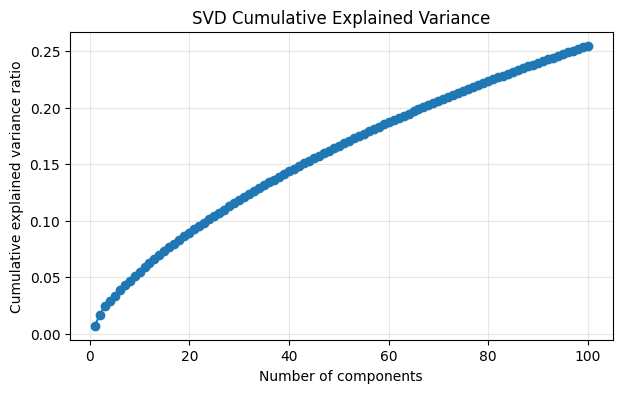

In [59]:
start = time.perf_counter()

svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_train_svd = svd.fit_transform(X_train_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

lr_svd = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
lr_svd.fit(X_train_svd, y_train)
y_pred_svd = lr_svd.predict(X_test_svd)

elapsed_svd = time.perf_counter() - start
res_svd = evaluate_binary_model("Model 2: TF-IDF -> SVD -> LogisticRegression", y_test, y_pred_svd, elapsed_svd)

cum_var_svd = np.cumsum(svd.explained_variance_ratio_)
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cum_var_svd) + 1), cum_var_svd, marker="o")
plt.title("SVD Cumulative Explained Variance")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance ratio")
plt.grid(True, alpha=0.3)
plt.show()

### Step 6 + 7: PCA + Logistic Regression


=== Model 3: TF-IDF -> PCA -> LogisticRegression ===
Time (s):   2.4054
Accuracy:   0.9727
Precision:  0.8984
Recall:     0.8984
F1-score:   0.8984

Classification report:

              precision    recall  f1-score   support

           0     0.9842    0.9842    0.9842      1206
           1     0.8984    0.8984    0.8984       187

    accuracy                         0.9727      1393
   macro avg     0.9413    0.9413    0.9413      1393
weighted avg     0.9727    0.9727    0.9727      1393

Confusion matrix:
 [[1187   19]
 [  19  168]]


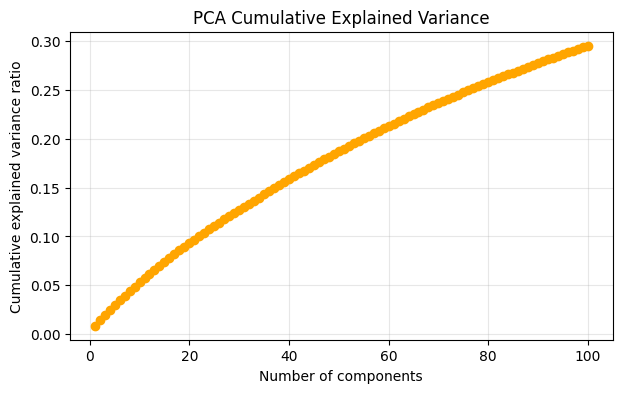

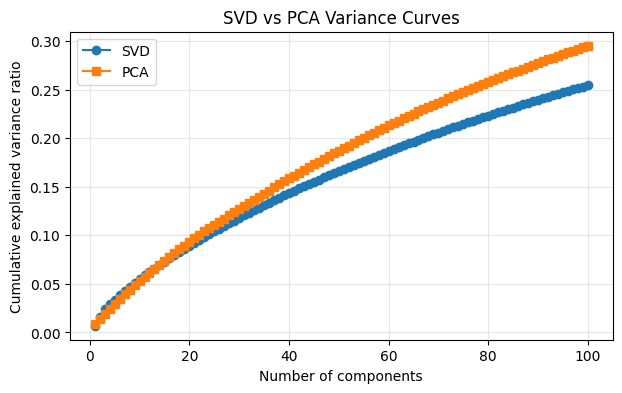

In [60]:
start = time.perf_counter()

X_train_dense = X_train_tfidf.toarray()
X_test_dense = X_test_tfidf.toarray()

scaler = StandardScaler(with_mean=True, with_std=True)
X_train_scaled = scaler.fit_transform(X_train_dense)
X_test_scaled = scaler.transform(X_test_dense)

pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

lr_pca = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
lr_pca.fit(X_train_pca, y_train)
y_pred_pca = lr_pca.predict(X_test_pca)

elapsed_pca = time.perf_counter() - start
res_pca = evaluate_binary_model("Model 3: TF-IDF -> PCA -> LogisticRegression", y_test, y_pred_pca, elapsed_pca)

cum_var_pca = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cum_var_pca) + 1), cum_var_pca, marker="o", color="orange")
plt.title("PCA Cumulative Explained Variance")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance ratio")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cum_var_svd) + 1), cum_var_svd, label="SVD", marker="o")
plt.plot(range(1, len(cum_var_pca) + 1), cum_var_pca, label="PCA", marker="s")
plt.title("SVD vs PCA Variance Curves")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance ratio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Step 8: Visual comparison and final analysis

In [61]:
results = [res_nb, res_svd, res_pca]
summary_df = pd.DataFrame([{k: v for k, v in r.items() if k != "cm"} for r in results])
summary_df = summary_df[["model", "accuracy", "precision", "recall", "f1", "time_sec"]]
summary_df

,model,accuracy,precision,recall,f1,time_sec
0,Model 1: TF-IDF + Naive Bayes,0.974156,1.000000,0.807487,0.893491,0.003116
1,Model 2: TF-IDF -> SVD -> LogisticRegression,0.949749,0.975610,0.641711,0.774194,0.086331
2,Model 3: TF-IDF -> PCA -> LogisticRegression,0.972721,0.898396,0.898396,0.898396,2.405383


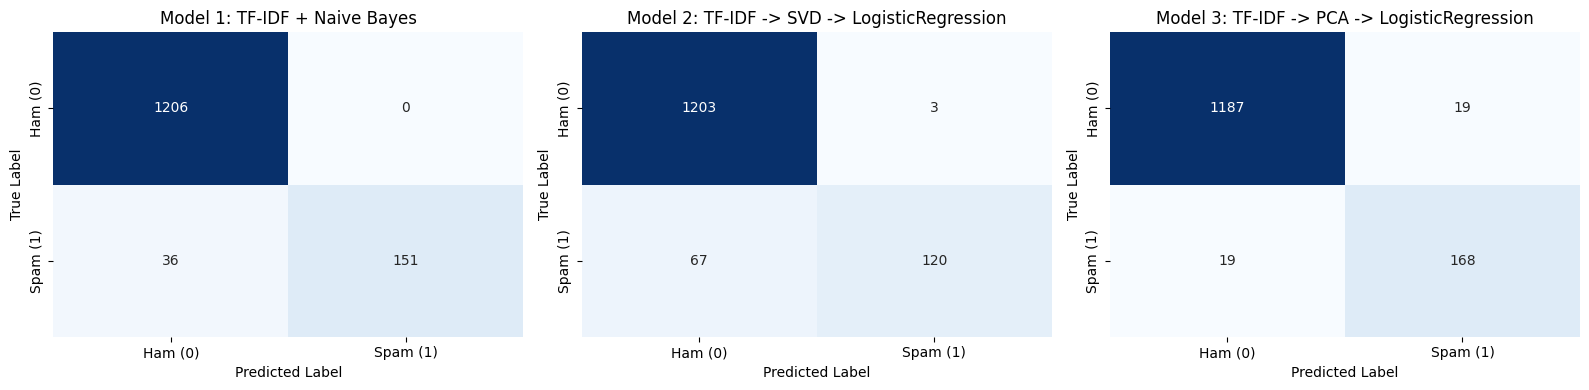

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, r in zip(axes, results):
    sns.heatmap(
        r["cm"],
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        xticklabels=["Ham (0)", "Spam (1)"],
        yticklabels=["Ham (0)", "Spam (1)"],
    )
    ax.set_title(r["model"])
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.tight_layout()
plt.show()

## Interpretation Template (Fill After Running)

- Which model had the best F1-score?
- Which model was fastest (`time_sec`)?
- For each confusion matrix, compare false positives vs false negatives.
- Which class is harder to predict (ham or spam)? Why?
- Did dimensionality reduction (SVD/PCA) improve or reduce performance versus baseline NB?
- For chatbot usage, what errors matter most for user experience?

## Refactored Experimental Pipeline (Clean Comparison)

This section provides a single reusable evaluation flow to compare:

- TF-IDF + Naive Bayes
- TF-IDF + TruncatedSVD + Logistic Regression
- TF-IDF + PCA + Logistic Regression
- OpenAI Embeddings + Logistic Regression (optional, runs only if API key is configured)

Use this as the final experiment output for your report and AI receptionist research notes.

In [63]:
import os
import time
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

RAW_DATA_PATH = Path("SMSSpamCollection")
TEST_SIZE = 0.25
RANDOM_STATE = 42
MAX_FEATURES = 5000
N_COMPONENTS = 100

if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset file not found: {RAW_DATA_PATH}")

df_ref = pd.read_csv(RAW_DATA_PATH, sep="\t", header=None, names=["raw_label", "text"])
df_ref["label"] = (df_ref["raw_label"].str.lower() == "spam").astype(int)
df_ref = df_ref[["text", "label"]].dropna().copy()

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df_ref["text"],
    df_ref["label"],
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df_ref["label"],
)

print("Dataset size:", len(df_ref))
print("Train/Test:", len(X_train_text), len(X_test_text))
print("Class counts:\n", df_ref["label"].value_counts())

Dataset size: 5572
Train/Test: 4179 1393
Class counts:
 label
0    4825
1     747
Name: count, dtype: int64


In [64]:
def eval_model(model_name, y_true, y_pred, elapsed_sec):
    cm = confusion_matrix(y_true, y_pred)
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "time_sec": elapsed_sec,
        "fp": int(cm[0, 1]),
        "fn": int(cm[1, 0]),
        "cm": cm,
    }


def plot_cm_grid(cm_map):
    models = list(cm_map.keys())
    cols = len(models)
    fig, axes = plt.subplots(1, cols, figsize=(5 * cols, 4))
    if cols == 1:
        axes = [axes]

    for ax, model in zip(axes, models):
        cm = cm_map[model]
        im = ax.imshow(cm, cmap="Blues")
        ax.set_title(model)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(["Ham (0)", "Spam (1)"])
        ax.set_yticklabels(["Ham (0)", "Spam (1)"])
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()


results = []
cm_map = {}

In [65]:
# Shared TF-IDF features for the three required rubric models
tfidf = TfidfVectorizer(
    max_features=MAX_FEATURES,
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print("Vocabulary size:", len(tfidf.vocabulary_))
print("TF-IDF train shape:", X_train_tfidf.shape)

# 1) Baseline: TF-IDF + Naive Bayes
start = time.perf_counter()
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)
elapsed = time.perf_counter() - start
r = eval_model("TF-IDF + NB", y_test, y_pred_nb, elapsed)
results.append({k: v for k, v in r.items() if k != "cm"})
cm_map[r["model"]] = r["cm"]

# 2) TF-IDF + SVD + Logistic Regression
start = time.perf_counter()
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_train_svd = svd.fit_transform(X_train_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

lr_svd = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
lr_svd.fit(X_train_svd, y_train)
y_pred_svd = lr_svd.predict(X_test_svd)
elapsed = time.perf_counter() - start
r = eval_model("TF-IDF + SVD + LR", y_test, y_pred_svd, elapsed)
results.append({k: v for k, v in r.items() if k != "cm"})
cm_map[r["model"]] = r["cm"]

# 3) TF-IDF + PCA + Logistic Regression
start = time.perf_counter()
X_train_dense = X_train_tfidf.toarray()
X_test_dense = X_test_tfidf.toarray()

scaler = StandardScaler(with_mean=True, with_std=True)
X_train_scaled = scaler.fit_transform(X_train_dense)
X_test_scaled = scaler.transform(X_test_dense)

pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

lr_pca = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
lr_pca.fit(X_train_pca, y_train)
y_pred_pca = lr_pca.predict(X_test_pca)
elapsed = time.perf_counter() - start
r = eval_model("TF-IDF + PCA + LR", y_test, y_pred_pca, elapsed)
results.append({k: v for k, v in r.items() if k != "cm"})
cm_map[r["model"]] = r["cm"]

# 4) Optional extension: OpenAI embeddings + Logistic Regression
# Runs only when OPENAI_API_KEY is present and openai package is installed.
if os.getenv("OPENAI_API_KEY"):
    try:
        from openai import OpenAI

        def _ek(text, model):
            return hashlib.sha256(f"{model}::{text}".encode("utf-8")).hexdigest()

        def _embed_all(client, texts, model="text-embedding-3-small", batch_size=64):
            cache = {}
            vecs = []
            missing = [t for t in texts if _ek(t, model) not in cache]
            for i in range(0, len(missing), batch_size):
                batch = missing[i : i + batch_size]
                resp = client.embeddings.create(model=model, input=batch)
                for txt, item in zip(batch, resp.data):
                    cache[_ek(txt, model)] = item.embedding
            for t in texts:
                vecs.append(cache[_ek(t, model)])
            return np.array(vecs, dtype=np.float32)

        start = time.perf_counter()
        client = OpenAI()
        X_train_emb = _embed_all(client, X_train_text.tolist())
        X_test_emb = _embed_all(client, X_test_text.tolist())

        lr_emb = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
        lr_emb.fit(X_train_emb, y_train)
        y_pred_emb = lr_emb.predict(X_test_emb)
        elapsed = time.perf_counter() - start

        r = eval_model("OpenAI Embedding + LR", y_test, y_pred_emb, elapsed)
        results.append({k: v for k, v in r.items() if k != "cm"})
        cm_map[r["model"]] = r["cm"]
    except Exception as e:
        print("Skipping OpenAI model due to runtime issue:", e)
else:
    print("OPENAI_API_KEY not found: skipping OpenAI embedding comparison.")

Vocabulary size: 5000
TF-IDF train shape: (4179, 5000)


In [66]:
comparison_df = pd.DataFrame(results).sort_values("f1", ascending=False).reset_index(drop=True)
comparison_df

,model,accuracy,precision,recall,f1,time_sec,fp,fn
0,OpenAI Embedding + LR,0.992821,1.000000,0.946524,0.972527,71.152436,0,10
1,TF-IDF + PCA + LR,0.972721,0.898396,0.898396,0.898396,1.044367,19,19
2,TF-IDF + NB,0.974156,1.000000,0.807487,0.893491,0.001210,0,36
3,TF-IDF + SVD + LR,0.949749,0.975610,0.641711,0.774194,0.072824,3,67


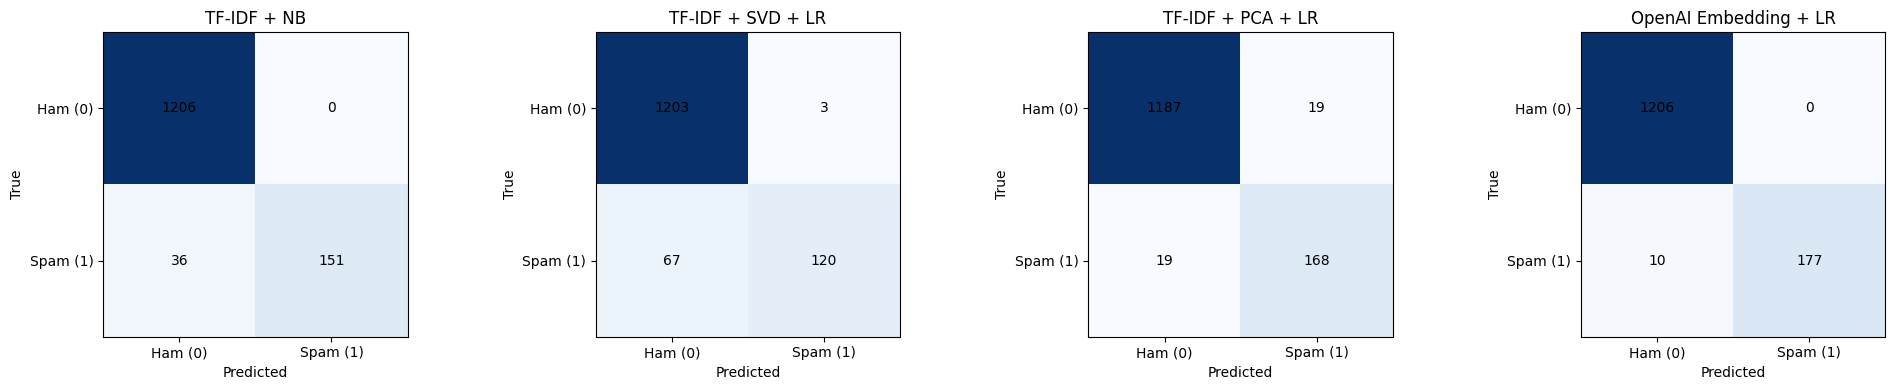

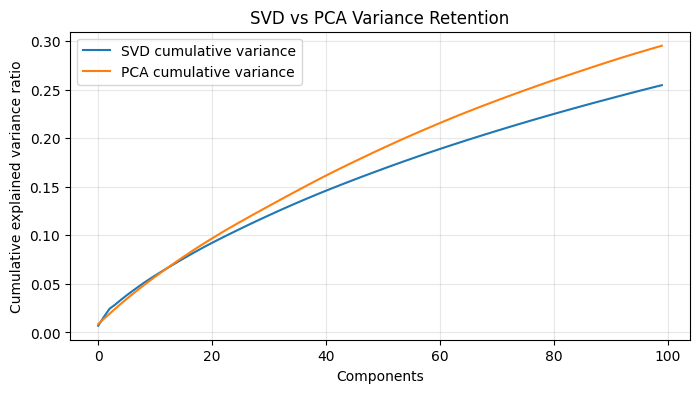

In [67]:
plot_cm_grid(cm_map)

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(svd.explained_variance_ratio_), label="SVD cumulative variance")
plt.plot(np.cumsum(pca.explained_variance_ratio_), label="PCA cumulative variance")
plt.title("SVD vs PCA Variance Retention")
plt.xlabel("Components")
plt.ylabel("Cumulative explained variance ratio")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Final Comparison Notes

Use `comparison_df` and confusion matrices to document:

- Best model by F1-score
- Fastest model by `time_sec`
- FP/FN tradeoff (important for chatbot intent reliability)
- Whether dimensionality reduction (SVD/PCA) improved performance over TF-IDF baseline
- Whether OpenAI embeddings are worth added latency/cost for your AI receptionist use case